<a href="https://colab.research.google.com/github/michael-palomino-tm/Ingenier-a-de-Soluciones-con-Inteligencia-Artificial/blob/Mistral/RA2/IL2.1/5_langgraph_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 5. Orquestación de Agentes y Flujos con LangGraph

## Objetivos de Aprendizaje

- Comprender la diferencia conceptual entre **CrewAI** y **LangGraph**.
- Reconocer los componentes principales de LangGraph: **estado, nodos y aristas**.
- Reutilizar un mismo agente investigador para ejecutar más de una tarea.
- Modelar dependencias entre tareas mediante el **estado compartido** del grafo.
- Ejecutar dos investigaciones independientes y utilizar ambos resultados como contexto para una tarea final de escritura.
- Visualizar cómo LangGraph permite combinar pasos **agentic** (decididos por un LLM) con una orquestación explícita y controlada.

## ¿Qué aporta LangGraph?

CrewAI expresa el trabajo en términos de **agentes, tareas y equipos**. LangGraph propone una abstracción diferente: modelamos la aplicación como un **grafo de ejecución**.

En este ejemplo construiremos el siguiente flujo:

```text
                   ┌──────────────────────┐
             ┌────►│ Investigar Curie     │────┐
             │     └──────────────────────┘    │
START ───────┤                               ├────► Escritor ─────► END
             │     ┌──────────────────────┐    │
             └────►│ Investigar Einstein  │────┘
                   └──────────────────────┘
```

Los dos nodos de investigación reutilizan el **mismo agente investigador**, pero producen resultados distintos.  
El nodo escritor depende de ambos resultados.

### Equivalencia conceptual aproximada

| CrewAI | LangGraph |
|---|---|
| `Agent` | agente/runnable que puede ser usado dentro de un nodo |
| `Task` | nodo o trabajo ejecutado dentro de un nodo |
| `context=[task1, task2]` | datos almacenados en el estado y consumidos por otro nodo |
| `Crew` | grafo compilado |
| `Process.sequential` | aristas que imponen un orden |
| dependencias entre tareas | aristas + campos del estado |

> **Idea clave:** LangGraph no obliga a pensar primero en “roles”. Obliga a hacer explícito **qué información existe, quién la produce y qué paso necesita esa información**.


## 1. Instalación y configuración

In [1]:

# --- Instalación de dependencias (solo en Google Colab) ---
# En local se recomienda instalar las dependencias desde requirements.txt.
import sys

if "google.colab" in sys.modules:
    !pip install -q langgraph langchain langchain-openai python-dotenv requests


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.1/572.1 kB 46.9 MB/s eta 0:00:00



## 2. Credenciales del proveedor de LLM

Usaremos un proveedor compatible con la API de OpenAI, igual que en los notebooks anteriores.

El notebook espera las siguientes variables:

- `LLM_API_KEY`: clave del proveedor.
- `LLM_BASE_URL`: URL base de la API.
- `LLM_MODEL`: modelo principal.

En Google Colab pueden guardarse como **Secrets**; en local pueden leerse desde un archivo `.env`.


In [2]:

# --- Credenciales: Google Colab Secrets o archivo .env ---
import os

try:
    from google.colab import userdata

    for _k in (
        "LLM_API_KEY",
        "LANGSMITH_API_KEY",
        "LLM_BASE_URL",
        "LLM_MODEL",
        "LLM_MODEL_SMALL",
    ):
        try:
            value = userdata.get(_k)
            if value:
                os.environ[_k] = value
        except Exception:
            pass

    os.environ.setdefault("LLM_BASE_URL", "https://api.mistral.ai/v1")
    os.environ.setdefault("LLM_MODEL", "mistral-small-latest")
    os.environ.setdefault("LLM_MODEL_SMALL", "ministral-8b-latest")

except ImportError:
    from dotenv import load_dotenv
    load_dotenv()

print("🔍 Verificando configuración:")
print(f"LLM_BASE_URL: {os.environ.get('LLM_BASE_URL', '❌ No configurado')}")
print(f"LLM_MODEL   : {os.environ.get('LLM_MODEL', '❌ No configurado')}")
print(f"LLM_API_KEY : {'✅ Configurado' if os.environ.get('LLM_API_KEY') else '❌ No configurado'}")


🔍 Verificando configuración:
LLM_BASE_URL: https://api.mistral.ai/v1
LLM_MODEL   : ministral-14b-latest
LLM_API_KEY : ✅ Configurado



## 3. Configuración del LLM

LangGraph no impone un proveedor específico de modelos. En este ejemplo utilizamos `ChatOpenAI` porque permite conectarnos a un endpoint compatible con el protocolo de OpenAI mediante `base_url`.

Este objeto será reutilizado por:

1. el **agente investigador**, que dispone de una herramienta;
2. el **nodo escritor**, que recibe los resultados de las investigaciones y redacta el texto final.


In [3]:

from langchain_openai import ChatOpenAI

try:
    llm = ChatOpenAI(
        model=os.getenv("LLM_MODEL", "mistral-small-latest"),
        base_url=os.getenv("LLM_BASE_URL"),
        api_key=os.getenv("LLM_API_KEY"),
        temperature=0,
    )

    test = llm.invoke("Responde solamente: funcionando")
    print("✅ LLM configurado correctamente.")
    print(f"📝 Respuesta de prueba: {test.content}")

except Exception as e:
    print(f"❌ Error configurando el LLM: {e}")
    llm = None


✅ LLM configurado correctamente.
📝 Respuesta de prueba: ¡Funcionando! 🚀



## 4. Definición de la herramienta de Wikipedia

Seguimos utilizando una herramienta externa para obtener información factual.

En vez de la librería `wikipedia`, consultamos directamente la API de MediaWiki mediante `requests`.  
Esto nos permite enviar explícitamente un `User-Agent`, requisito de acceso de Wikimedia que provocó errores `403` en los ejemplos anteriores.

El decorador `@tool` transforma la función Python en una herramienta que puede ser utilizada por un agente de LangChain.


In [4]:

import requests
from langchain_core.tools import tool

@tool
def get_wikipedia_summary(query: str) -> str:
    """
    Busca en Wikipedia en español un tema y devuelve su introducción enciclopédica.
    Es útil para obtener información factual sobre personas, lugares, conceptos
    históricos, científicos u otros temas generales.
    """

    url = "https://es.wikipedia.org/w/api.php"

    headers = {
        "User-Agent": "DuocUC-AgentDemo/1.0 (curso académico de IA)"
    }

    params = {
        "action": "query",
        "prop": "extracts",
        "exintro": True,
        "explaintext": True,
        "titles": query,
        "format": "json",
        "formatversion": 2,
    }

    try:
        response = requests.get(
            url,
            params=params,
            headers=headers,
            timeout=10,
        )
        response.raise_for_status()

        data = response.json()
        pages = data.get("query", {}).get("pages", [])

        if not pages:
            return f"No se encontró información para '{query}'."

        page = pages[0]

        if page.get("missing"):
            return f"No se encontró ninguna página para '{query}'."

        extract = page.get("extract", "").strip()

        if not extract:
            return f"La página de Wikipedia para '{query}' no contiene un resumen disponible."

        return extract

    except requests.exceptions.RequestException as e:
        return f"Error de comunicación con Wikipedia: {e}"

    except ValueError as e:
        return f"Error al interpretar la respuesta de Wikipedia: {e}"

    except Exception as e:
        return f"Error inesperado al consultar Wikipedia: {e}"


tools = [get_wikipedia_summary]

print("✅ Herramienta definida.")


✅ Herramienta definida.



### Prueba aislada de la herramienta

Antes de incorporarla al agente, conviene comprobar la herramienta en forma independiente.

Esto separa dos posibles fuentes de error:

```text
¿Falla la herramienta?  → problema de integración/API
¿Funciona la herramienta pero falla el agente? → problema de orquestación o uso de tools
```


In [5]:

test_result = get_wikipedia_summary.invoke({"query": "Albert Einstein"})

if test_result.lower().startswith("error"):
    print("❌ La herramienta devolvió un error:")
    print(test_result)
else:
    print("✅ Herramienta probada correctamente.")
    print("📝 Primeros 500 caracteres:")
    print(test_result[:500])


✅ Herramienta probada correctamente.
📝 Primeros 500 caracteres:
Albert Einstein pronunciación en alemán: /ˈalbɐt ˈaɪnʃtaɪn/ ();​ (Ulm, 14 de marzo de 1879-Princeton, Nueva Jersey, 18 de abril de 1955) fue un físico alemán de origen judío, nacionalizado después suizo, austriaco y estadounidense. Se le considera el científico más importante, conocido y popular del siglo XX.​​
En 1905, cuando era un joven físico desconocido, empleado en la Oficina de Patentes de Berna, publicó su teoría de la relatividad especial. En ella incorporó, en un marco teórico simple f



## 5. Creación de un agente investigador reutilizable

En CrewAI definíamos un `Agent` con un rol y luego le asignábamos distintas `Task`.

Aquí utilizaremos `create_agent()` para construir un **agente investigador** que conoce la herramienta de Wikipedia.

La idea importante es que **el mismo agente se reutilizará desde dos nodos diferentes**:

```text
Agente investigador
      ↑        ↑
      │        │
 nodo Curie   nodo Einstein
```

Los nodos representan trabajos concretos; el agente representa una capacidad reutilizable.


In [6]:

from langchain.agents import create_agent

researcher_agent = create_agent(
    model=llm,
    tools=tools,
    system_prompt="""
Eres un investigador académico especializado en historia de la ciencia.

Tu trabajo es obtener información factual utilizando la herramienta de Wikipedia
disponible y luego producir un resumen claro, preciso y bien organizado.

Reglas:
- Utiliza Wikipedia antes de redactar el resumen.
- Basa el resumen en la información obtenida mediante la herramienta.
- Si la herramienta informa un error, indícalo; no reemplaces silenciosamente
  la fuente externa con información inventada.
- No escribas todavía una biografía literaria: entrega material de investigación
  que pueda utilizar otro agente o etapa posterior.
""",
)

print("✅ Agente investigador creado.")


✅ Agente investigador creado.



## 6. El estado: la “memoria de trabajo” del grafo

Una diferencia central respecto de CrewAI es que ahora declaramos explícitamente **qué información circula entre los pasos**.

El estado tendrá tres campos principales:

- `curie_research`: resultado de la investigación sobre Marie Curie.
- `einstein_research`: resultado de la investigación sobre Albert Einstein.
- `final_text`: texto producido por el escritor.

`StateGraph` irá actualizando este objeto a medida que avanza el flujo.

> El estado no es necesariamente memoria persistente. En este ejemplo es simplemente el conjunto de datos compartidos durante una ejecución del grafo.


In [7]:

from typing import TypedDict

class WorkflowState(TypedDict):
    curie_research: str
    einstein_research: str
    final_text: str



## 7. Nodos de investigación

Cada nodo recibe el estado actual y devuelve **solo los campos que modifica**.

Los dos nodos usan el mismo `researcher_agent`, pero realizan trabajos diferentes.

Esto es equivalente a tener en CrewAI:

```python
task_1 = Task(..., agent=researcher)
task_2 = Task(..., agent=researcher)
```

La diferencia es que en LangGraph nosotros hacemos explícito dónde se guarda el resultado de cada trabajo.


In [8]:

def _extract_final_message(agent_result) -> str:
    """Extrae el contenido del último mensaje producido por un agente."""
    messages = agent_result.get("messages", [])
    if not messages:
        return "El agente no produjo una respuesta."
    return str(messages[-1].content)


def research_curie(state: WorkflowState):
    print("🔎 Nodo research_curie: investigando a Marie Curie...")

    result = researcher_agent.invoke({
        "messages": [{
            "role": "user",
            "content": """
Investiga a Marie Curie.

Enfócate en:
- datos biográficos clave;
- descubrimientos científicos;
- premios y reconocimientos;
- impacto científico y social;
- legado.

Entrega un resumen factual de aproximadamente 4 a 6 párrafos.
"""
        }]
    })

    research = _extract_final_message(result)
    print("✅ Investigación de Marie Curie completada.")

    return {"curie_research": research}


def research_einstein(state: WorkflowState):
    print("🔎 Nodo research_einstein: investigando a Albert Einstein...")

    result = researcher_agent.invoke({
        "messages": [{
            "role": "user",
            "content": """
Investiga a Albert Einstein.

Enfócate en:
- datos biográficos clave;
- contribuciones científicas;
- premios y reconocimientos;
- impacto científico y social;
- legado.

Entrega un resumen factual de aproximadamente 4 a 6 párrafos.
"""
        }]
    })

    research = _extract_final_message(result)
    print("✅ Investigación de Albert Einstein completada.")

    return {"einstein_research": research}



## 8. Nodo escritor y dependencia de información

El escritor no necesita consultar Wikipedia.

Su trabajo comienza **después** de que las dos investigaciones han producido información.

En CrewAI expresábamos esta dependencia con:

```python
context=[curie_task, einstein_task]
```

En LangGraph la expresamos de dos maneras:

1. las **aristas** indican que el escritor no debe ejecutarse antes de las investigaciones;
2. el **estado** contiene `curie_research` y `einstein_research`, que el escritor utiliza como entrada.

```text
curie_research ──────┐
                     ├──► writer
einstein_research ───┘
```


In [9]:

from langchain_core.messages import SystemMessage, HumanMessage

def write_comparison(state: WorkflowState):
    print("✍️ Nodo writer: integrando ambas investigaciones...")

    prompt = f"""
Utiliza EXCLUSIVAMENTE las dos investigaciones entregadas a continuación para
redactar un texto comparativo sobre Marie Curie y Albert Einstein.

INVESTIGACIÓN SOBRE MARIE CURIE
-------------------------------
{state["curie_research"]}

INVESTIGACIÓN SOBRE ALBERT EINSTEIN
-----------------------------------
{state["einstein_research"]}

Requisitos:
- presentar brevemente a ambos científicos;
- destacar sus principales contribuciones;
- comparar el tipo de impacto que tuvieron en la ciencia;
- identificar similitudes y diferencias relevantes;
- usar un tono divulgativo, preciso y accesible;
- estructurar el resultado en Markdown con encabezados;
- no incorporar datos que no aparezcan en las investigaciones proporcionadas.
"""

    response = llm.invoke([
        SystemMessage(content=(
            "Eres un escritor de divulgación científica. "
            "Transformas investigación previa en textos claros y rigurosos."
        )),
        HumanMessage(content=prompt),
    ])

    print("✅ Texto comparativo completado.")

    return {"final_text": response.content}



## 9. Construcción del grafo

Ahora definimos explícitamente la arquitectura del workflow.

Las dos investigaciones parten desde `START`, por lo que son ramas independientes.  
El escritor tiene una **dependencia conjunta**: solo debe ejecutarse después de que ambas ramas hayan terminado.

```text
                   research_curie ──────┐
START ────────────┤                    ├──► writer ───► END
                   research_einstein ───┘
```

Esta es una diferencia pedagógica importante respecto de CrewAI:

- CrewAI permite expresar la colaboración en un nivel más declarativo.
- LangGraph hace visible la **topología del flujo** y el **estado que conecta los pasos**.


In [10]:

from langgraph.graph import StateGraph, START, END

builder = StateGraph(WorkflowState)

# Registrar los nodos
builder.add_node("research_curie", research_curie)
builder.add_node("research_einstein", research_einstein)
builder.add_node("writer", write_comparison)

# Dos ramas independientes parten desde START
builder.add_edge(START, "research_curie")
builder.add_edge(START, "research_einstein")

# El writer espera los resultados de AMBAS investigaciones
builder.add_edge(
    ["research_curie", "research_einstein"],
    "writer"
)

builder.add_edge("writer", END)

graph = builder.compile()

print("✅ Grafo compilado correctamente.")


✅ Grafo compilado correctamente.



### Visualización textual del grafo

LangGraph puede generar una representación Mermaid de la estructura.  
En algunos entornos puede renderizarse gráficamente; aquí imprimimos el código para observar la topología sin depender de servicios externos.


In [11]:

print(graph.get_graph().draw_mermaid())


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	research_curie(research_curie)
	research_einstein(research_einstein)
	writer(writer)
	__end__([<p>__end__</p>]):::last
	__start__ --> research_curie;
	__start__ --> research_einstein;
	research_curie --> writer;
	research_einstein --> writer;
	writer --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



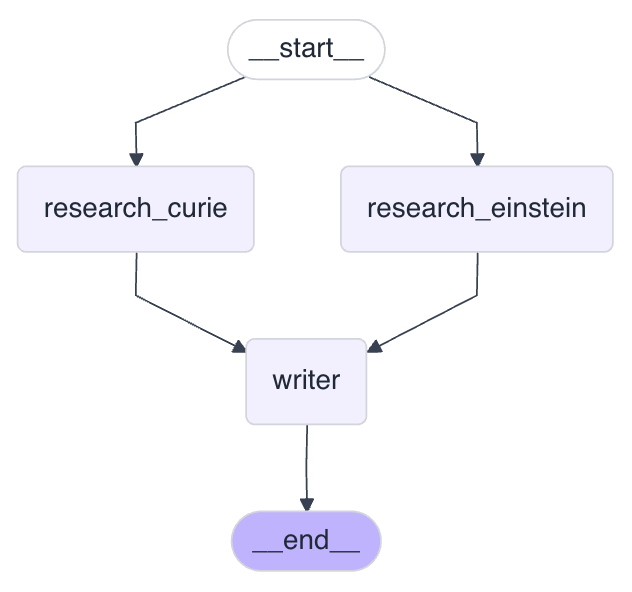


## 10. Ejecución del grafo

El estado inicial contiene los campos vacíos. Cada nodo irá completando los valores que le corresponden.

Durante la ejecución observa los mensajes:

```text
🔎 research_curie
🔎 research_einstein
✍️ writer
```

Los dos primeros nodos son independientes. El escritor, en cambio, depende de ambos.

> A diferencia del ejemplo con CrewAI, aquí no necesitamos `kickoff()`. Ejecutamos directamente el grafo compilado mediante `invoke()`.


In [12]:

if llm is None:
    print("❌ No se puede ejecutar el grafo sin un LLM configurado.")
else:
    initial_state = {
        "curie_research": "",
        "einstein_research": "",
        "final_text": "",
    }

    try:
        print("🚀 Iniciando ejecución del grafo...\n")

        result = graph.invoke(initial_state)

        print("\n" + "=" * 80)
        print("🏁 RESULTADO FINAL")
        print("=" * 80)
        print(result["final_text"])

    except Exception as e:
        print(f"❌ Error durante la ejecución del grafo: {e}")


🚀 Iniciando ejecución del grafo...

🔎 Nodo research_curie: investigando a Marie Curie...
🔎 Nodo research_einstein: investigando a Albert Einstein...
✅ Investigación de Marie Curie completada.
✅ Investigación de Albert Einstein completada.
✍️ Nodo writer: integrando ambas investigaciones...
✅ Texto comparativo completado.

🏁 RESULTADO FINAL
# **Marie Curie y Albert Einstein: Dos Genios que Revolucionaron la Ciencia**

## **Introducción: Dos Mentes que Cambiaron el Mundo**
Marie Curie y Albert Einstein son dos de los científicos más influyentes del siglo XX, cuyas contribuciones transformaron la física, la química y nuestra comprensión del universo. Aunque trabajaron en áreas distintas —ella en la radiactividad y sus aplicaciones médicas, él en la teoría del espacio, el tiempo y la energía—, ambos compartieron un rasgo fundamental: **una curiosidad insaciable y una capacidad única para desafiar las ideas establecidas**. Sin embargo, sus trayectorias, métodos y legados presentaron diferen


## 11. Inspección del estado final

Además del texto final, LangGraph devuelve el **estado completo**.

Esto permite inspeccionar qué produjo cada paso:

```python
result["curie_research"]
result["einstein_research"]
result["final_text"]
```

Esta visibilidad del estado es especialmente útil para depuración, trazabilidad y workflows complejos.


In [13]:

if "result" in globals():
    print("📦 Campos disponibles en el estado final:")
    for key in result:
        print(f"- {key}: {len(str(result[key]))} caracteres")


📦 Campos disponibles en el estado final:
- curie_research: 4179 caracteres
- einstein_research: 4236 caracteres
- final_text: 8447 caracteres



## 12. Comparación conceptual: CrewAI vs LangGraph

### En CrewAI

```text
Agent investigador
   ├── Task Curie
   └── Task Einstein

Agent escritor
   └── Task escritura
          ↑
   context=[Task Curie, Task Einstein]
```

### En LangGraph

```text
                    ┌─ research_curie ──────┐
START ──────────────┤                       ├── writer ── END
                    └─ research_einstein ───┘

Estado:
{
    curie_research,
    einstein_research,
    final_text
}
```

### Diferencia principal

**CrewAI pone el énfasis en los roles y la colaboración entre agentes.**

**LangGraph pone el énfasis en el estado, las dependencias y el flujo de ejecución.**

Ambos enfoques pueden resolver el mismo problema, pero hacen visibles aspectos distintos de la arquitectura.



## 🎓 Conclusiones

1. **Un mismo agente puede reutilizarse en distintos nodos.**  
   El investigador se utiliza tanto para Marie Curie como para Albert Einstein.

2. **Los nodos representan trabajos concretos.**  
   Cada nodo recibe un estado, ejecuta una operación y devuelve una actualización.

3. **El estado reemplaza conceptualmente parte del `context` de CrewAI.**  
   Los resultados se guardan explícitamente en campos que otros nodos pueden consumir.

4. **Las aristas representan dependencias.**  
   El nodo escritor se ejecuta solamente después de que estén disponibles las dos investigaciones.

5. **LangGraph separa la orquestación de la inteligencia del agente.**  
   El grafo controla el flujo; los LLM y agentes realizan los pasos que requieren interpretación o generación.

6. **Un workflow puede mezclar pasos agentic y determinísticos.**  
   No todo nodo necesita ser un agente autónomo. Esta combinación permite mayor control y trazabilidad.

### Pregunta de reflexión

> Si las investigaciones de Marie Curie y Albert Einstein son independientes, ¿qué ventaja podría tener ejecutarlas en paralelo? ¿Qué cambiaría si la segunda investigación necesitara el resultado de la primera?
